# E-Commerce Customer Segmentation & Sales Analysis

**Dataset**: Online Retail Dataset (UCI ML Repository)

In this analysis, I'll be exploring e-commerce transaction data to understand customer behavior and identify opportunities for business growth. The main goals are:

- Segment customers using RFM (Recency, Frequency, Monetary) analysis
- Identify sales patterns and trends
- Analyze geographic and product performance
- Build a cohort analysis to understand retention


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# basic setup
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)


## Loading the Data

Using the Online Retail dataset from UCI - it contains about a year of transactions from a UK retailer.


In [2]:
# load the excel file
df = pd.read_excel('Online_Retail.xlsx')
print(f"Loaded {len(df)} rows")
df.head()


Loaded 541909 rows


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
# quick look at the data types and missing values
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())


InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [4]:
# looks like ~25% of CustomerID is missing - need to drop those for customer analysis
# also some negative quantities which are probably returns

df_clean = df.copy()

# drop missing customer IDs - can't do customer segmentation without them
df_clean = df_clean.dropna(subset=['CustomerID'])

# filter out returns (negative qty) and zero/negative prices
df_clean = df_clean[df_clean['Quantity'] > 0]
df_clean = df_clean[df_clean['UnitPrice'] > 0]

# add some useful columns
df_clean['TotalAmount'] = df_clean['Quantity'] * df_clean['UnitPrice']
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['Year'] = df_clean['InvoiceDate'].dt.year
df_clean['Month'] = df_clean['InvoiceDate'].dt.month
df_clean['Weekday'] = df_clean['InvoiceDate'].dt.day_name()
df_clean['Hour'] = df_clean['InvoiceDate'].dt.hour

print(f"Cleaned data: {len(df_clean)} rows")
print(f"Date range: {df_clean['InvoiceDate'].min().date()} to {df_clean['InvoiceDate'].max().date()}")
print(f"Customers: {df_clean['CustomerID'].nunique()}")


Cleaned data: 397884 rows
Date range: 2010-12-01 to 2011-12-09
Customers: 4338


## Quick Business Overview


In [5]:
# let's see some high level metrics
total_rev = df_clean['TotalAmount'].sum()
num_customers = df_clean['CustomerID'].nunique()
num_orders = df_clean['InvoiceNo'].nunique()
avg_order = total_rev / num_orders

print(f"Total Revenue: £{total_rev:,.0f}")
print(f"Unique Customers: {num_customers:,}")
print(f"Total Orders: {num_orders:,}")
print(f"Avg Order Value: £{avg_order:.2f}")


Total Revenue: £8,911,408
Unique Customers: 4,338
Total Orders: 18,532
Avg Order Value: £480.87


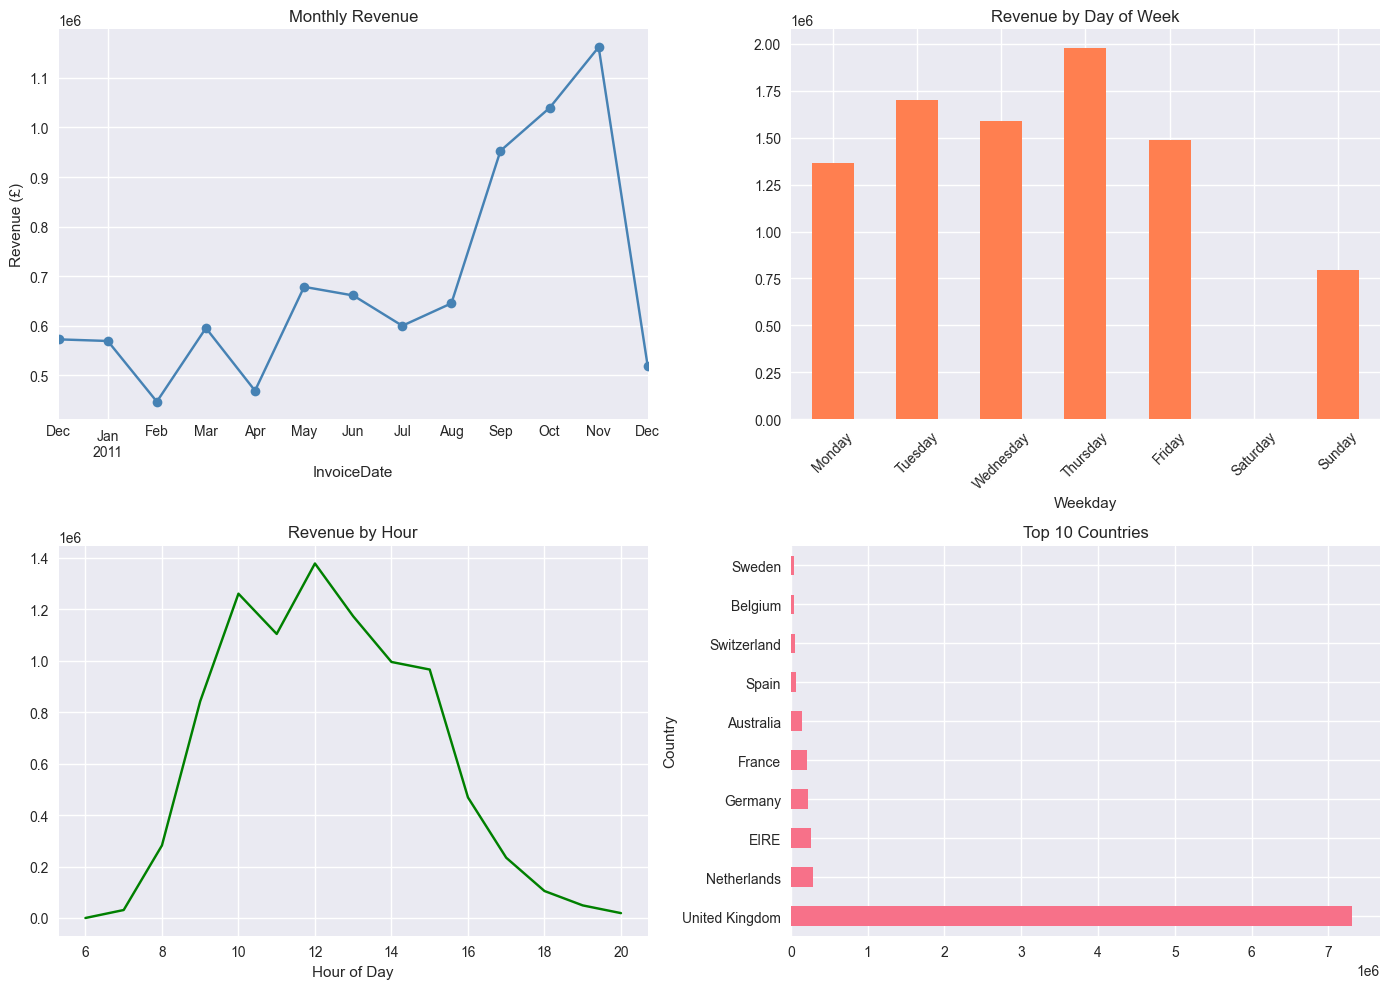

In [6]:
# sales trends
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# monthly trend
monthly = df_clean.groupby(df_clean['InvoiceDate'].dt.to_period('M'))['TotalAmount'].sum()
monthly.plot(ax=axes[0,0], color='steelblue', marker='o')
axes[0,0].set_title('Monthly Revenue')
axes[0,0].set_ylabel('Revenue (£)')

# by day of week
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily = df_clean.groupby('Weekday')['TotalAmount'].sum().reindex(weekday_order)
daily.plot(kind='bar', ax=axes[0,1], color='coral')
axes[0,1].set_title('Revenue by Day of Week')
axes[0,1].tick_params(axis='x', rotation=45)

# hourly pattern
hourly = df_clean.groupby('Hour')['TotalAmount'].sum()
hourly.plot(ax=axes[1,0], color='green')
axes[1,0].set_title('Revenue by Hour')
axes[1,0].set_xlabel('Hour of Day')

# top countries
top_countries = df_clean.groupby('Country')['TotalAmount'].sum().nlargest(10)
top_countries.plot(kind='barh', ax=axes[1,1])
axes[1,1].set_title('Top 10 Countries')

plt.tight_layout()
plt.show()


## RFM Customer Segmentation

RFM is a classic approach - looking at how recently someone bought (Recency), how often (Frequency), and how much (Monetary).


In [7]:
# calculate RFM for each customer
# using day after last transaction as reference point
snapshot_date = df_clean['InvoiceDate'].max() + timedelta(days=1)

rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
})
rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.describe()


,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


In [8]:
# score each dimension 1-5 using quantiles
# for recency, lower is better so we reverse the labels
rfm['R'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])
rfm['F'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm['M'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])

rfm['RFM_Score'] = rfm['R'].astype(int) + rfm['F'].astype(int) + rfm['M'].astype(int)
rfm.head()


,Recency,Frequency,Monetary,R,F,M,RFM_Score
CustomerID,,,,,,,
12346.0,326,1,77183.60,1,1,5,7
12347.0,2,7,4310.00,5,5,5,15
12348.0,75,4,1797.24,2,4,4,10
12349.0,19,1,1757.55,4,1,4,9
12350.0,310,1,334.40,1,1,2,4


In [9]:
# create segments based on combined score
def get_segment(score):
    if score >= 13:
        return 'Champions'
    elif score >= 11:
        return 'Loyal'
    elif score >= 9:
        return 'Potential Loyal'
    elif score >= 7:
        return 'New/Promising'
    elif score >= 5:
        return 'At Risk'
    else:
        return 'Lost'

rfm['Segment'] = rfm['RFM_Score'].apply(get_segment)

# see the breakdown
seg_summary = rfm.groupby('Segment').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'sum']
})
seg_summary.columns = ['Avg_Recency', 'Avg_Frequency', 'Avg_Monetary', 'Total_Revenue']
seg_summary['Count'] = rfm.groupby('Segment').size()
seg_summary['Rev_Pct'] = (seg_summary['Total_Revenue'] / seg_summary['Total_Revenue'].sum() * 100).round(1)

seg_summary.sort_values('Count', ascending=False)


,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue,Count,Rev_Pct
Segment,,,,,,
Champions,14.614561,11.739829,6697.362452,6255336.530,934,70.2
At Risk,147.272727,1.227931,342.395113,259877.891,759,2.9
New/Promising,91.648613,1.789960,690.927902,523032.422,757,5.9
Potential Loyal,63.243722,2.776957,1061.911462,718914.060,677,8.1
Loyal,37.328829,4.279279,1575.519656,1049296.091,666,11.8
Lost,254.932110,1.009174,192.570477,104950.910,545,1.2


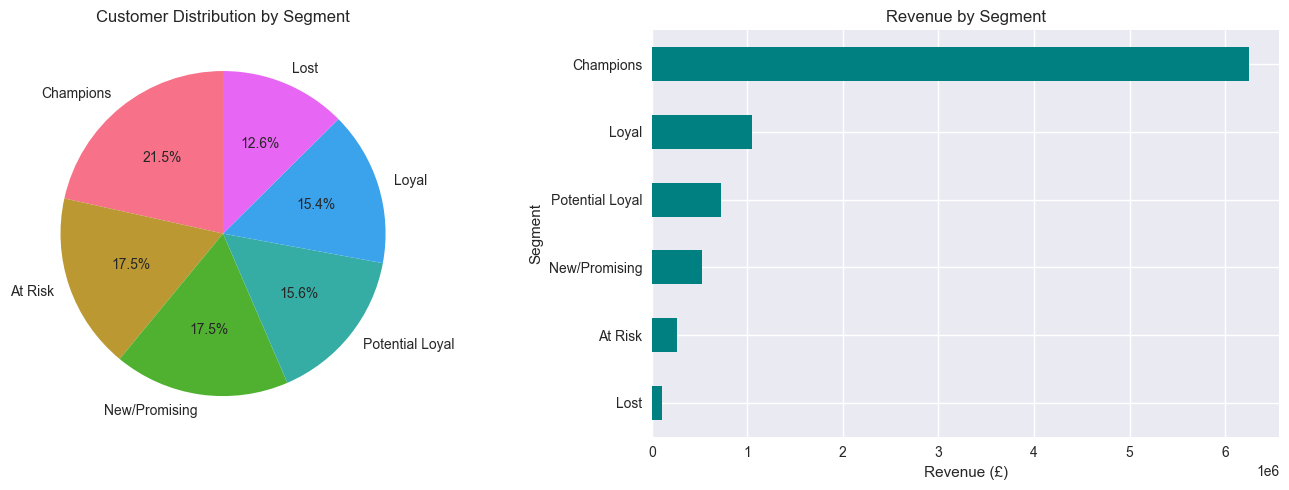


Champions are 21.5% of customers but drive 70.2% of revenue


In [10]:
# visualize the segments
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# pie chart of customer distribution
seg_counts = rfm['Segment'].value_counts()
axes[0].pie(seg_counts, labels=seg_counts.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Customer Distribution by Segment')

# revenue by segment
seg_summary['Total_Revenue'].sort_values().plot(kind='barh', ax=axes[1], color='teal')
axes[1].set_title('Revenue by Segment')
axes[1].set_xlabel('Revenue (£)')

plt.tight_layout()
plt.show()

# key insight
print(f"\nChampions are {seg_summary.loc['Champions', 'Count']/len(rfm)*100:.1f}% of customers but drive {seg_summary.loc['Champions', 'Rev_Pct']}% of revenue")


## Product & Geographic Analysis


In [11]:
# top products by revenue
products = df_clean.groupby(['StockCode', 'Description']).agg({
    'Quantity': 'sum',
    'TotalAmount': 'sum',
    'CustomerID': 'nunique'
}).sort_values('TotalAmount', ascending=False)
products.columns = ['Qty_Sold', 'Revenue', 'Unique_Buyers']

print("Top 10 Products by Revenue:")
products.head(10)


Top 10 Products by Revenue:


,,Qty_Sold,Revenue,Unique_Buyers
StockCode,Description,,,
23843,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60,1
22423,REGENCY CAKESTAND 3 TIER,12402,142592.95,881
85123A,WHITE HANGING HEART T-LIGHT HOLDER,36725,100448.15,856
85099B,JUMBO BAG RED RETROSPOT,46181,85220.78,635
23166,MEDIUM CERAMIC TOP STORAGE JAR,77916,81416.73,138
POST,POSTAGE,3120,77803.96,331
47566,PARTY BUNTING,15291,68844.33,708
84879,ASSORTED COLOUR BIRD ORNAMENT,35362,56580.34,678
M,Manual,7173,53779.93,197


In [12]:
# geographic breakdown
geo = df_clean.groupby('Country').agg({
    'TotalAmount': 'sum',
    'CustomerID': 'nunique',
    'InvoiceNo': 'nunique'
})
geo.columns = ['Revenue', 'Customers', 'Orders']
geo['Rev_per_Customer'] = geo['Revenue'] / geo['Customers']
geo = geo.sort_values('Revenue', ascending=False)

print("Top 10 Countries:")
print(geo.head(10))

# UK dominance
uk_pct = geo.loc['United Kingdom', 'Revenue'] / geo['Revenue'].sum() * 100
print(f"\nUK accounts for {uk_pct:.1f}% of total revenue")


Top 10 Countries:
                    Revenue  Customers  Orders  Rev_per_Customer
Country                                                         
United Kingdom  7308391.554       3920   16646       1864.385601
Netherlands      285446.340          9      94      31716.260000
EIRE             265545.900          3     260      88515.300000
Germany          228867.140         94     457       2434.756809
France           209024.050         87     389       2402.575287
Australia        138521.310          9      57      15391.256667
Spain             61577.110         30      90       2052.570333
Switzerland       56443.950         21      51       2687.807143
Belgium           41196.340         25      98       1647.853600
Sweden            38378.330          8      36       4797.291250

UK accounts for 82.0% of total revenue


## Cohort Retention Analysis

Looking at how well we retain customers over time based on their first purchase month.


In [13]:
# assign each customer to their first purchase month (cohort)
df_clean['OrderMonth'] = df_clean['InvoiceDate'].dt.to_period('M').astype(str)
first_purchase = df_clean.groupby('CustomerID')['InvoiceDate'].min().dt.to_period('M').astype(str)
df_clean['Cohort'] = df_clean['CustomerID'].map(first_purchase)

# count unique customers per cohort per month
cohort_data = df_clean.groupby(['Cohort', 'OrderMonth'])['CustomerID'].nunique().reset_index()
cohort_sizes = df_clean.groupby('Cohort')['CustomerID'].nunique()

# calculate months since first purchase
cohort_data['Period'] = (pd.to_datetime(cohort_data['OrderMonth']) - 
                         pd.to_datetime(cohort_data['Cohort'])).dt.days // 30

# pivot for heatmap
cohort_data = cohort_data.drop_duplicates(['Cohort', 'Period'])
cohort_pivot = cohort_data.pivot(index='Cohort', columns='Period', values='CustomerID')

# convert to retention rate
for col in cohort_pivot.columns:
    cohort_pivot[col] = cohort_pivot[col] / cohort_sizes

cohort_pivot = cohort_pivot.fillna(0)


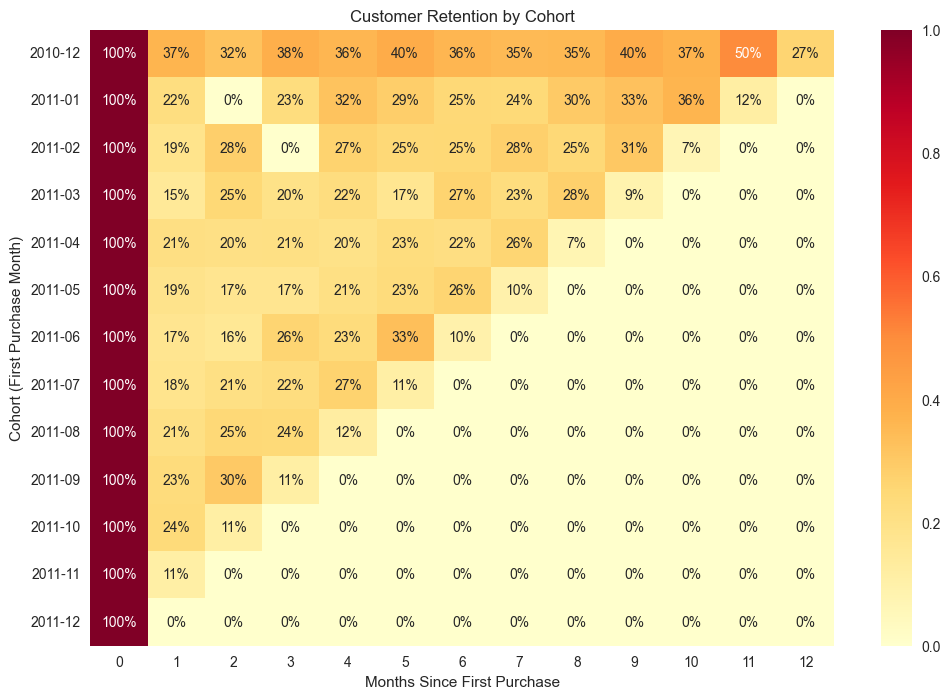

Average Retention Rates:
  Month 0: 100.0%
  Month 1: 19.0%
  Month 2: 17.4%
  Month 3: 15.7%
  Month 4: 17.0%
  Month 5: 15.4%
  Month 6: 13.1%


In [14]:
# plot the retention heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(cohort_pivot, annot=True, fmt='.0%', cmap='YlOrRd')
plt.title('Customer Retention by Cohort')
plt.xlabel('Months Since First Purchase')
plt.ylabel('Cohort (First Purchase Month)')
plt.show()

# average retention by month
avg_ret = cohort_pivot.mean()
print("Average Retention Rates:")
for i, rate in avg_ret.items():
    if i <= 6:
        print(f"  Month {i}: {rate:.1%}")


## Key Takeaways


In [15]:
# pulling together the key findings
print("=" * 50)
print("SUMMARY OF FINDINGS")
print("=" * 50)

print("\n1. CUSTOMER SEGMENTS:")
print(f"   - Champions: {seg_summary.loc['Champions', 'Count']} customers ({seg_summary.loc['Champions', 'Rev_Pct']}% of revenue)")
print(f"   - At Risk: {seg_summary.loc['At Risk', 'Count']} customers need attention")
print(f"   - Lost: {seg_summary.loc['Lost', 'Count']} customers to potentially win back")

print("\n2. SALES PATTERNS:")
print(f"   - Peak month: {monthly.idxmax()}")
print(f"   - Best day: {daily.idxmax()}")
print(f"   - Peak hour: {hourly.idxmax()}:00")

print("\n3. GEOGRAPHIC:")
print(f"   - UK = {uk_pct:.0f}% of revenue")
print(f"   - International growth opportunity: {100-uk_pct:.0f}%")

print("\n4. RETENTION:")
print(f"   - Month 1 retention: {avg_ret[1]:.1%}")
print(f"   - Month 6 retention: {avg_ret[6]:.1%}" if 6 in avg_ret.index else "")

print("\n" + "=" * 50)
print("RECOMMENDATIONS")
print("=" * 50)
print("\n- Focus on Champions with VIP treatment/early access")
print("- Win-back campaigns for At Risk segment")
print("- Explore international markets (EIRE, Netherlands show high per-customer value)")
print("- Schedule promotions on Thursdays around noon")


SUMMARY OF FINDINGS

1. CUSTOMER SEGMENTS:
   - Champions: 934 customers (70.2% of revenue)
   - At Risk: 759 customers need attention
   - Lost: 545 customers to potentially win back

2. SALES PATTERNS:
   - Peak month: 2011-11
   - Best day: Thursday
   - Peak hour: 12:00

3. GEOGRAPHIC:
   - UK = 82% of revenue
   - International growth opportunity: 18%

4. RETENTION:
   - Month 1 retention: 19.0%
   - Month 6 retention: 13.1%

RECOMMENDATIONS

- Focus on Champions with VIP treatment/early access
- Win-back campaigns for At Risk segment
- Explore international markets (EIRE, Netherlands show high per-customer value)
- Schedule promotions on Thursdays around noon
